# Codigo 1

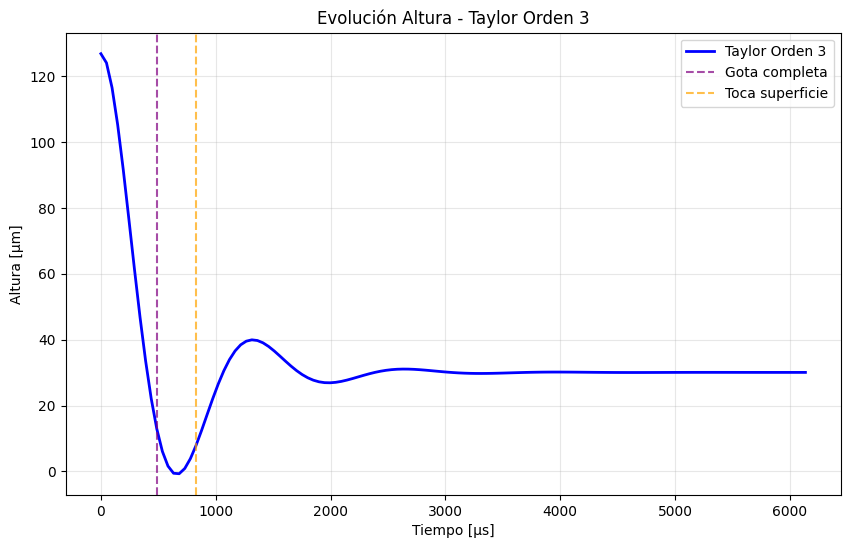

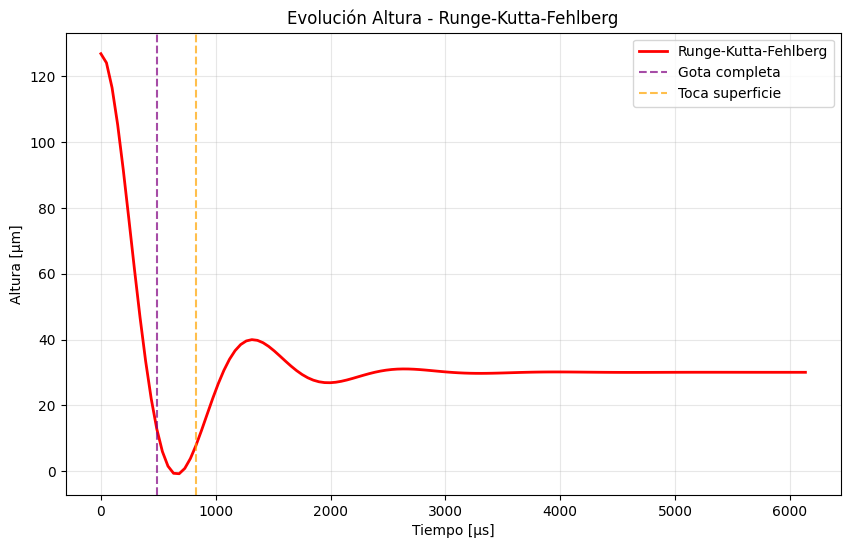

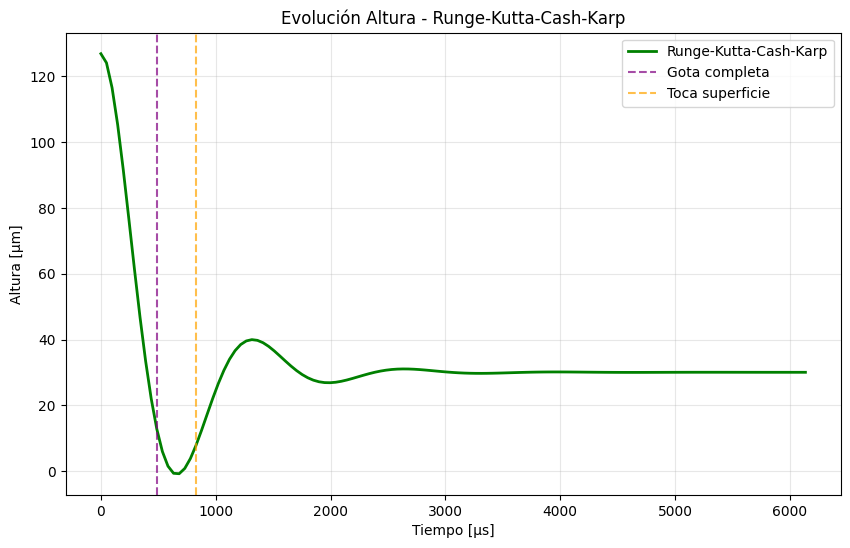

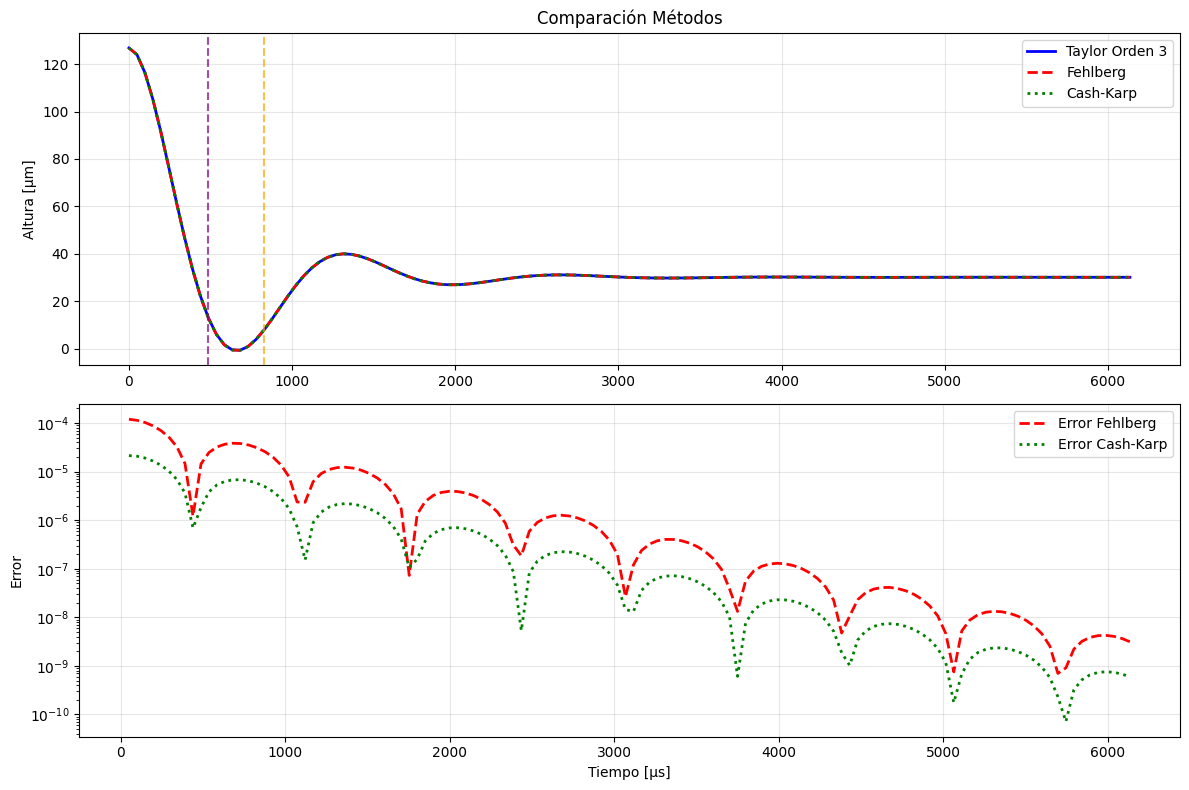

RESUMEN EJECUCIÓN
Pasos Taylor: 127, Altura final: 30.08 µm
Pasos Fehlberg: 127, Altura final: 30.08 µm
Pasos Cash-Karp: 127, Altura final: 30.08 µm
Error medio Fehlberg: 8.45e-06
Error medio Cash-Karp: 1.56e-06


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTES
t0, y0, v0 = 0.0, 126.85, 0.0
u0 = np.array([y0, v0])
m0 = 0.000000105
k0 = 2.560942495392004e-5 * m0
c0 = 0.003449017165742452 * m0
yeq0, h0, tf = 30.08, 48.69, 6086.28
t_eventos = [486.90, 827.73]

class ODESolver:
    def f(self, t, u):
        u1, u2 = u
        return np.array([u2, (-c0/m0)*u2 - (k0/m0)*(u1-yeq0)])

    def taylor3(self):
        t, u, ts, us = t0, u0.copy(), [t0], [u0.copy()]
        while t <= tf:
            u1, u2 = u
            # Derivadas
            u1d = u2
            u2d = (-c0/m0)*u2 - (k0/m0)*(u1-yeq0)
            u1dd = u2d
            u2dd = (-c0/m0)*u2d - (k0/m0)*u1d
            u1ddd = u2dd
            u2ddd = (-c0/m0)*u2dd - (k0/m0)*u1dd
            # Taylor orden 3
            u1_n = u1 + u1d*h0 + (h0**2)/2*u1dd + (h0**3)/6*u1ddd
            u2_n = u2 + u2d*h0 + (h0**2)/2*u2dd + (h0**3)/6*u2ddd
            u = np.array([u1_n, u2_n])
            t += h0
            ts.append(t); us.append(u.copy())
        return np.array(ts), np.array(us)

    def rk_paso(self, t, u, h, a, b, c5, c6):
        k = []
        for i in range(6):
            ui = u if i == 0 else u + h * sum(b[i][j] * k[j] for j in range(i))
            k.append(self.f(t + a[i]*h, ui))
        s5 = u + h * sum(ci*ki for ci, ki in zip(c5, k))
        s6 = u + h * sum(ci*ki for ci, ki in zip(c6, k))
        return s6, np.linalg.norm(s6 - s5)

    def fehlberg(self):
        a = [0, 1/4, 3/8, 12/13, 1, 1/2]
        b = [[], [1/4], [3/32, 9/32], [1932/2197, -7200/2197, 7296/2197],
             [439/216, -8, 3680/513, -845/4104], [-8/27, 2, -3544/2565, 1859/4104, -11/40]]
        c5 = [25/216, 0, 1408/2565, 2197/4104, -1/5, 0]
        c6 = [16/135, 0, 6656/12825, 28561/56430, -9/50, 2/55]

        t, u, ts, us, es = t0, u0.copy(), [t0], [u0.copy()], [np.nan]
        while t <= tf:
            u, e = self.rk_paso(t, u, h0, a, b, c5, c6)
            t += h0
            ts.append(t); us.append(u.copy()); es.append(e)
        return np.array(ts), np.array(us), np.array(es)

    def cash_karp(self):
        a = [0, 1/5, 3/10, 3/5, 1, 7/8]
        b = [[], [1/5], [3/40, 9/40], [3/10, -9/10, 6/5],
             [-11/54, 5/2, -70/27, 35/27], [1631/55296, 175/512, 575/13824, 44275/110592, 253/4096]]
        c5 = [37/378, 0, 250/621, 125/594, 0, 512/1771]
        c6 = [2825/27648, 0, 18575/48384, 13525/55296, 277/14336, 1/4]

        t, u, ts, us, es = t0, u0.copy(), [t0], [u0.copy()], [np.nan]
        while t <= tf:
            u, e = self.rk_paso(t, u, h0, a, b, c5, c6)
            t += h0
            ts.append(t); us.append(u.copy()); es.append(e)
        return np.array(ts), np.array(us), np.array(es)

# EJECUCIÓN Y GRÁFICOS
solver = ODESolver()

# Taylor
t_tay, u_tay = solver.taylor3()
plt.figure(figsize=(10, 6))
plt.plot(t_tay, u_tay[:, 0], 'b-', label='Taylor Orden 3', linewidth=2)
for te, color, label in zip(t_eventos, ['purple', 'orange'], ['Gota completa', 'Toca superficie']):
    plt.axvline(x=te, color=color, linestyle='--', label=label, alpha=0.7)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Evolución Altura - Taylor Orden 3")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Fehlberg
t_feh, u_feh, e_feh = solver.fehlberg()
plt.figure(figsize=(10, 6))
plt.plot(t_feh, u_feh[:, 0], 'r-', label='Runge-Kutta-Fehlberg', linewidth=2)
for te, color, label in zip(t_eventos, ['purple', 'orange'], ['Gota completa', 'Toca superficie']):
    plt.axvline(x=te, color=color, linestyle='--', label=label, alpha=0.7)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Evolución Altura - Runge-Kutta-Fehlberg")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Cash-Karp
t_ck, u_ck, e_ck = solver.cash_karp()
plt.figure(figsize=(10, 6))
plt.plot(t_ck, u_ck[:, 0], 'g-', label='Runge-Kutta-Cash-Karp', linewidth=2)
for te, color, label in zip(t_eventos, ['purple', 'orange'], ['Gota completa', 'Toca superficie']):
    plt.axvline(x=te, color=color, linestyle='--', label=label, alpha=0.7)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Evolución Altura - Runge-Kutta-Cash-Karp")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Comparativa
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t_tay, u_tay[:, 0], 'b-', label='Taylor Orden 3', linewidth=2)
plt.plot(t_feh, u_feh[:, 0], 'r--', label='Fehlberg', linewidth=2)
plt.plot(t_ck, u_ck[:, 0], 'g:', label='Cash-Karp', linewidth=2)
for te, color, label in zip(t_eventos, ['purple', 'orange'], ['Gota completa', 'Toca superficie']):
    plt.axvline(x=te, color=color, linestyle='--', alpha=0.7)
plt.ylabel("Altura [µm]"); plt.title("Comparación Métodos"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.semilogy(t_feh, e_feh, 'r--', label='Error Fehlberg', linewidth=2)
plt.semilogy(t_ck, e_ck, 'g:', label='Error Cash-Karp', linewidth=2)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Error"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Análisis
print("="*40)
print("RESUMEN EJECUCIÓN")
print("="*40)
print(f"Pasos Taylor: {len(t_tay)}, Altura final: {u_tay[-1, 0]:.2f} µm")
print(f"Pasos Fehlberg: {len(t_feh)}, Altura final: {u_feh[-1, 0]:.2f} µm")
print(f"Pasos Cash-Karp: {len(t_ck)}, Altura final: {u_ck[-1, 0]:.2f} µm")
print(f"Error medio Fehlberg: {np.nanmean(e_feh):.2e}")
print(f"Error medio Cash-Karp: {np.nanmean(e_ck):.2e}")

## Codigo Ploty

In [ ]:
# ============================================
# ODE con gráficos interactivos (Plotly)
# ============================================
!pip -q install plotly

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# CONSTANTES
t0, y0, v0 = 0.0, 126.85, 0.0
u0 = np.array([y0, v0])
m0 = 330.3591814941233
k0 = 2.560942495392004e-5 * m0
c0 = 0.003549017165742452 * m0
yeq0, h0, tf = 30.08, 48.69, 6086.28
t_eventos = [486.90, 827.73]  # [Gota completa, Toca superficie]

# =========================
# Solver
# =========================
class ODESolver:
    def f(self, t, u):
        u1, u2 = u
        return np.array([u2, (-c0/m0)*u2 - (k0/m0)*(u1-yeq0)])

    def taylor3(self):
        t, u, ts, us = t0, u0.copy(), [t0], [u0.copy()]
        while t <= tf:
            u1, u2 = u
            # Derivadas
            u1d = u2
            u2d = (-c0/m0)*u2 - (k0/m0)*(u1-yeq0)
            u1dd = u2d
            u2dd = (-c0/m0)*u2d - (k0/m0)*u1d
            u1ddd = u2dd
            u2ddd = (-c0/m0)*u2dd - (k0/m0)*u1dd
            # Taylor orden 3
            u1_n = u1 + u1d*h0 + (h0**2)/2*u1dd + (h0**3)/6*u1ddd
            u2_n = u2 + u2d*h0 + (h0**2)/2*u2dd + (h0**3)/6*u2ddd
            u = np.array([u1_n, u2_n])
            t += h0
            ts.append(t); us.append(u.copy())
        return np.array(ts), np.array(us)

    def rk_paso(self, t, u, h, a, b, c5, c6):
        k = []
        for i in range(6):
            ui = u if i == 0 else u + h * sum(b[i][j] * k[j] for j in range(i))
            k.append(self.f(t + a[i]*h, ui))
        s5 = u + h * sum(ci*ki for ci, ki in zip(c5, k))
        s6 = u + h * sum(ci*ki for ci, ki in zip(c6, k))
        return s6, np.linalg.norm(s6 - s5)

    def fehlberg(self):
        a = [0, 1/4, 3/8, 12/13, 1, 1/2]
        b = [[], [1/4], [3/32, 9/32], [1932/2197, -7200/2197, 7296/2197],
             [439/216, -8, 3680/513, -845/4104], [-8/27, 2, -3544/2565, 1859/4104, -11/40]]
        c5 = [25/216, 0, 1408/2565, 2197/4104, -1/5, 0]
        c6 = [16/135, 0, 6656/12825, 28561/56430, -9/50, 2/55]

        t, u, ts, us, es = t0, u0.copy(), [t0], [u0.copy()], [np.nan]
        while t <= tf:
            u, e = self.rk_paso(t, u, h0, a, b, c5, c6)
            t += h0
            ts.append(t); us.append(u.copy()); es.append(e)
        return np.array(ts), np.array(us), np.array(es)

    def cash_karp(self):
        a = [0, 1/5, 3/10, 3/5, 1, 7/8]
        b = [[], [1/5], [3/40, 9/40], [3/10, -9/10, 6/5],
             [-11/54, 5/2, -70/27, 35/27], [1631/55296, 175/512, 575/13824, 44275/110592, 253/4096]]
        c5 = [37/378, 0, 250/621, 125/594, 0, 512/1771]
        c6 = [2825/27648, 0, 18575/48384, 13525/55296, 277/14336, 1/4]

        t, u, ts, us, es = t0, u0.copy(), [t0], [u0.copy()], [np.nan]
        while t <= tf:
            u, e = self.rk_paso(t, u, h0, a, b, c5, c6)
            t += h0
            ts.append(t); us.append(u.copy()); es.append(e)
        return np.array(ts), np.array(us), np.array(es)

# =========================
# Ejecutar
# =========================
solver = ODESolver()

t_tay, u_tay = solver.taylor3()
t_feh, u_feh, e_feh = solver.fehlberg()
t_ck,  u_ck,  e_ck  = solver.cash_karp()

# Para que el log no truene con ceros:
e_feh_plot = np.where((~np.isfinite(e_feh)) | (e_feh<=0), np.nan, e_feh)
e_ck_plot  = np.where((~np.isfinite(e_ck))  | (e_ck<=0),  np.nan, e_ck)

# =========================
# Helpers para vlines
# =========================
def add_event_vlines(fig, eventos, labels, colors):
    # líneas atravesando todo el alto (paper) y ambas filas si hay subplots
    for x, lab, col in zip(eventos, labels, colors):
        fig.add_vline(
            x=x, line_width=2, line_dash="dash", line_color=col,
            annotation_text=lab, annotation_position="top right"
        )

# =========================
# Figura 1: Taylor
# =========================
fig_tay = go.Figure()
fig_tay.add_trace(go.Scatter(
    x=t_tay, y=u_tay[:,0],
    mode="lines", name="Taylor Orden 3",
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
))
add_event_vlines(fig_tay, t_eventos, ["Gota completa", "Toca superficie"], ["purple","orange"])
fig_tay.update_layout(
    title="Evolución Altura - Taylor Orden 3",
    xaxis_title="Tiempo [µs]",
    yaxis_title="Altura [µm]",
    template="plotly_white",
    height=520
)
fig_tay.show()

# =========================
# Figura 2: Fehlberg
# =========================
fig_feh = go.Figure()
fig_feh.add_trace(go.Scatter(
    x=t_feh, y=u_feh[:,0],
    mode="lines", name="Runge-Kutta-Fehlberg",
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
))
add_event_vlines(fig_feh, t_eventos, ["Gota completa", "Toca superficie"], ["purple","orange"])
fig_feh.update_layout(
    title="Evolución Altura - Runge-Kutta-Fehlberg",
    xaxis_title="Tiempo [µs]",
    yaxis_title="Altura [µm]",
    template="plotly_white",
    height=520
)
fig_feh.show()

# =========================
# Figura 3: Cash–Karp
# =========================
fig_ck = go.Figure()
fig_ck.add_trace(go.Scatter(
    x=t_ck, y=u_ck[:,0],
    mode="lines", name="Runge-Kutta-Cash-Karp",
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
))
add_event_vlines(fig_ck, t_eventos, ["Gota completa", "Toca superficie"], ["purple","orange"])
fig_ck.update_layout(
    title="Evolución Altura - Runge-Kutta-Cash-Karp",
    xaxis_title="Tiempo [µs]",
    yaxis_title="Altura [µm]",
    template="plotly_white",
    height=520
)
fig_ck.show()

# =========================
# Figura 4: Comparativa + errores (subplots)
# =========================
fig_cmp = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.08,
    subplot_titles=("Altura vs. Tiempo", "Error estimado (log)")
)


# Arriba: soluciones
fig_cmp.add_trace(go.Scatter(
    x=t_tay, y=u_tay[:,0], name="Taylor Orden 3", mode="lines",
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
), row=1, col=1)

fig_cmp.add_trace(go.Scatter(
    x=t_feh, y=u_feh[:,0], name="Fehlberg", mode="lines",
    line=dict(dash="dash"),
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
), row=1, col=1)

fig_cmp.add_trace(go.Scatter(
    x=t_ck, y=u_ck[:,0], name="Cash-Karp", mode="lines",
    line=dict(dash="dot"),
    hovertemplate="t = %{x:.2f} µs<br>y = %{y:.2f} µm<extra></extra>"
), row=1, col=1)

# Abajo: errores en log
fig_cmp.add_trace(go.Scatter(
    x=t_feh, y=e_feh_plot, name="Error Fehlberg", mode="lines",
    line=dict(dash="dash"),
    hovertemplate="t = %{x:.2f} µs<br>err = %{y:.3e}<extra></extra>"
), row=2, col=1)

fig_cmp.add_trace(go.Scatter(
    x=t_ck, y=e_ck_plot, name="Error Cash-Karp", mode="lines",
    line=dict(dash="dot"),
    hovertemplate="t = %{x:.2f} µs<br>err = %{y:.3e}<extra></extra>"
), row=2, col=1)

# Líneas de evento (atraviesan ambas filas)
for x in t_eventos:
    fig_cmp.add_vline(x=x, line_width=2, line_dash="dash", line_color="gray", opacity=0.6)

fig_cmp.update_yaxes(title_text="Altura [µm]", row=1, col=1)
fig_cmp.update_yaxes(title_text="Error", type="log", row=2, col=1)
fig_cmp.update_xaxes(title_text="Tiempo [µs]", row=2, col=1)

fig_cmp.update_layout(
    title="Comparación de Métodos (Altura + Error estimado)",
    template="plotly_white",
    height=720,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig_cmp.show()

# =========================
# Resumen
# =========================
print("="*40)
print("RESUMEN EJECUCIÓN")
print("="*40)
print(f"Pasos Taylor: {len(t_tay)}, Altura final: {u_tay[-1, 0]:.2f} µm")
print(f"Pasos Fehlberg: {len(t_feh)}, Altura final: {u_feh[-1, 0]:.2f} µm")
print(f"Pasos Cash-Karp: {len(t_ck)}, Altura final: {u_ck[-1, 0]:.2f} µm")
print(f"Error medio Fehlberg: {np.nanmean(e_feh):.2e}")
print(f"Error medio Cash-Karp: {np.nanmean(e_ck):.2e}")


RESUMEN EJECUCIÓN
Pasos Taylor: 127, Altura final: 30.08 µm
Pasos Fehlberg: 127, Altura final: 30.08 µm
Pasos Cash-Karp: 127, Altura final: 30.08 µm
Error medio Fehlberg: 8.25e-06
Error medio Cash-Karp: 1.52e-06


#Parte A

Sube 'centro_vs_tiempo.csv'


Saving centro_vs_tiempo.csv to centro_vs_tiempo (2).csv
===== Parámetros estimados (Punto A) =====
m       = 1.100e-07 kg
k       = 2.580e+00 N/m
c       = 4.204e-04 kg/s
yeq     = 124.59 µm
yinicial= 360.31 µm
v0      = -6.271e-01 m/s
Ingrese paso h para Taylor3 en segundos [default 4.87e-05]: 
Ingrese paso h para RK 5–6 en segundos [default 4.87e-05]: 

===== Configuración de integración =====
Taylor3: h = 4.87e-05 s
RK 5–6:  h = 4.87e-05 s


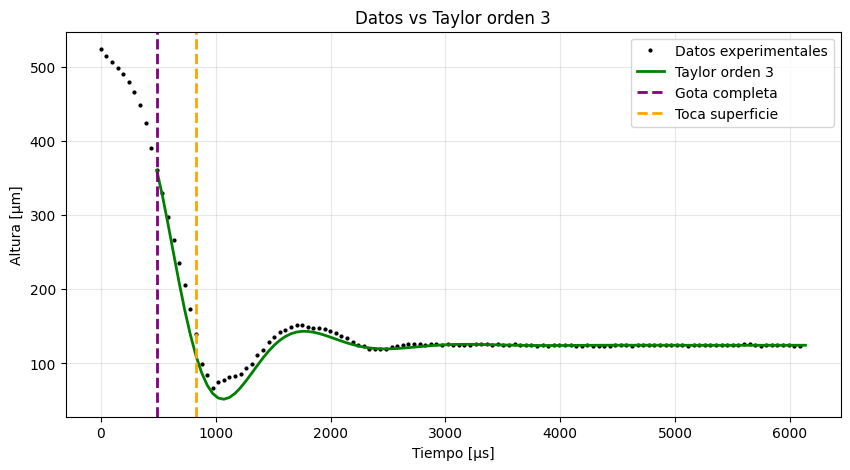

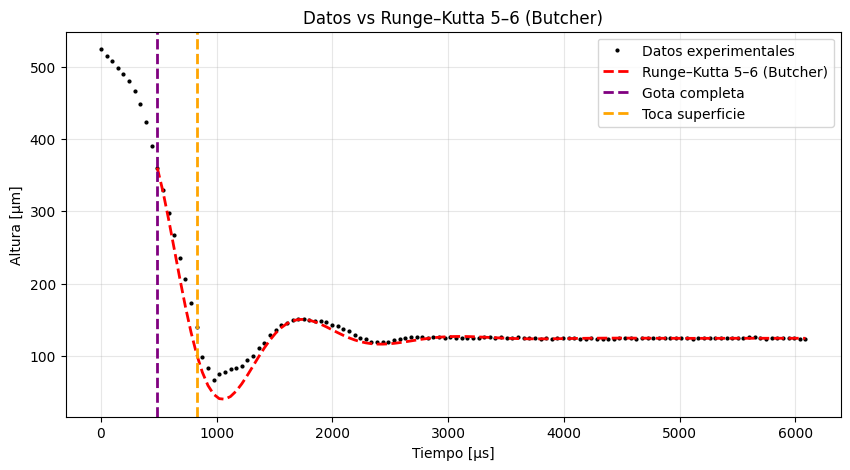

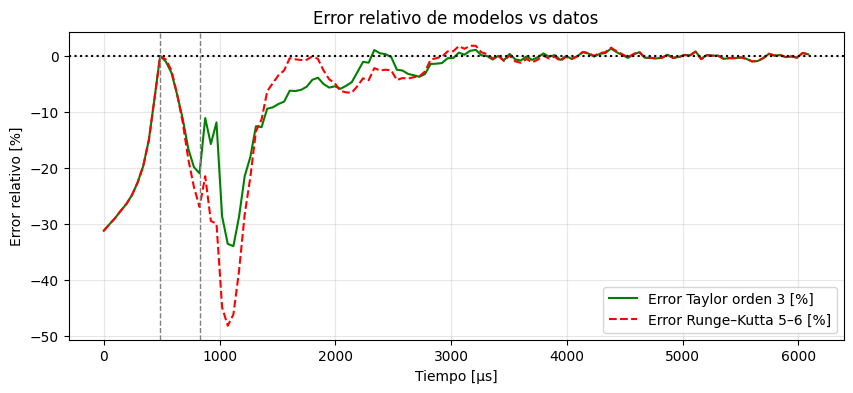

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from google.colab import files

# ==========================
# 1. CARGA Y CONVERSIÓN
# ==========================
px_to_um = 4.13             # µm/pixel
px_to_m  = px_to_um * 1e-6  # m/pixel

print("Sube 'centro_vs_tiempo.csv'")
files.upload()
df = pd.read_csv("centro_vs_tiempo.csv")

t_us = df["Tiempo en µs"].values.astype(float)
t_s  = t_us * 1e-6           # s
y_px = df["y_pixeles"].values.astype(float)
y_um = y_px * px_to_um       # µm
y_m  = y_um * 1e-6           # m

# ==========================
# 2. PARÁMETROS BÁSICOS
# ==========================
m = 0.110e-6                 # kg
t_events_us = [486.90, 827.73]  # µs
t0_event_s  = t_events_us[0] * 1e-6
h_data      = t_s[1] - t_s[0]   # paso de datos

# ==========================
# 3. FILTRAR DESDE "GOTA COMPLETA"
# ==========================
start_idx = np.searchsorted(t_s, t0_event_s)
t_us_sub  = t_us[start_idx:]
t_s_sub   = t_s[start_idx:]
y_um_sub  = y_um[start_idx:]
y_m_sub   = y_m[start_idx:]

# ==========================
# 4. ESTIMACIÓN DE PARÁMETROS FÍSICOS
# ==========================
yeq_um = np.median(y_um_sub[-10:])
z_sub  = y_um_sub - yeq_um
win    = max(7, 2*(len(z_sub)//100) + 1)
z_s    = savgol_filter(z_sub, window_length=win, polyorder=2)

peaks_max, _ = find_peaks(z_s, prominence=1.0)
peaks_min, _ = find_peaks(-z_s, prominence=1.0)
peaks_max = peaks_max[peaks_max != 0]
peaks_min = peaks_min[peaks_min != 0]

i_max1 = peaks_max[0]
i_min1 = peaks_min[0]
T1 = t_s_sub[i_max1] - t_s_sub[0]
T2 = 2 * abs(t_s_sub[i_max1] - t_s_sub[i_min1])
T_d = 0.5 * (T1 + T2)
f_d = 1.0 / T_d

A1, A2 = abs(z_s[peaks_max[0]]), abs(z_s[peaks_max[1]])
delta  = np.log(A1 / A2)
zeta   = delta / np.sqrt((2*np.pi)**2 + delta**2)

omega_d = 2*np.pi*f_d
omega_n = omega_d/np.sqrt(1 - zeta**2)
k       = m * omega_n**2
c       = 2 * m * omega_n * zeta
yeq_m   = yeq_um * 1e-6

# condiciones iniciales
y0 = y_m_sub[0]
v0 = (y_m_sub[1] - y_m_sub[0]) / h_data
u0 = np.array([y0, v0], dtype=float)
t_final = t_s_sub[-1] - t_s_sub[0]

print("===== Parámetros estimados (Punto A) =====")
print(f"m       = {m:.3e} kg")
print(f"k       = {k:.3e} N/m")
print(f"c       = {c:.3e} kg/s")
print(f"yeq     = {yeq_um:.2f} µm")
print(f"yinicial= {y_um_sub[0]:.2f} µm")
print(f"v0      = {v0:.3e} m/s")

# ==========================
# 5. SISTEMA DINÁMICO
# ==========================
def f_osc(u, m, k, c, yeq_m):
    y, v = u
    return np.array([v, -(c/m)*v - (k/m)*(y - yeq_m)], dtype=float)

# ==========================
# 6. TAYLOR ORDEN 3 (paso fijo)
# ==========================
def solve_taylor3(u0, h, tf, m, k, c, yeq_m):
    t = 0.0
    u = u0.copy()
    ts = [t]; ys = [u[0]]
    while t < tf - 1e-15:
        y, v = u
        y1 = v
        v1 = -(c/m)*v - (k/m)*(y - yeq_m)
        y2 = v1
        v2 = -(c/m)*v1 - (k/m)*y1
        y3 = v2
        v3 = -(c/m)*v2 - (k/m)*y2
        y_n = y + h*y1 + 0.5*h*h*y2 + (h**3)*y3/6.0
        v_n = v + h*v1 + 0.5*h*h*v2 + (h**3)*v3/6.0
        u   = np.array([y_n, v_n])
        t  += h
        ts.append(t); ys.append(u[0])
    return np.array(ts), np.array(ys)

# ==========================
# 7. RK 5–6 (Butcher, paso fijo)
# ==========================
def solve_rk56(u0, h, tf, m, k, c, yeq_m):
    # Coeficientes Butcher RK 5(6)
    b = [
        [],
        [1/6],
        [4/75, 16/75],
        [5/6, -8/3, 5/2],
        [-165/64, 55/6, -425/64, 85/96],
        [12/5, -8, 4015/612, -11/36, 88/255],
        [-8263/15000, 124/75, -643/680, -81/250, 2484/10625, 0]
    ]
    c5 = [13/160, 0, 2375/5984, 5/16, 12/85, 3/44, 0]
    c6 = [82889/524892, 0, 15625/83664, 69875/102672, -2260/8211, 0, 1/4]

    t = 0.0
    u = u0.copy()
    ts = [t]; ys = [u[0]]
    n_eval = 0  # 7 evaluaciones de f por paso

    while t < tf - 1e-15:
        if t + h > tf:
            h = tf - t

        k1 = f_osc(u, m,k,c,yeq_m)
        k2 = f_osc(u + h*(b[1][0]*k1), m,k,c,yeq_m)
        k3 = f_osc(u + h*(b[2][0]*k1 + b[2][1]*k2), m,k,c,yeq_m)
        k4 = f_osc(u + h*(b[3][0]*k1 + b[3][1]*k2 + b[3][2]*k3), m,k,c,yeq_m)
        k5 = f_osc(u + h*(b[4][0]*k1 + b[4][1]*k2 + b[4][2]*k3 + b[4][3]*k4), m,k,c,yeq_m)
        k6 = f_osc(u + h*(b[5][0]*k1 + b[5][1]*k2 + b[5][2]*k3 + b[5][3]*k4 + b[5][4]*k5), m,k,c,yeq_m)
        k7 = f_osc(u + h*(b[6][0]*k1 + b[6][1]*k2 + b[6][2]*k3 + b[6][3]*k4 + b[6][4]*k5 + b[6][5]*k6), m,k,c,yeq_m)

        # solución de orden 6 (u6); u5 disponible si querés estimar error local
        u6 = u + h*(c6[0]*k1 + c6[2]*k3 + c6[3]*k4 + c6[4]*k5 + c6[6]*k7)

        u = u6
        t += h
        ts.append(t); ys.append(u[0])
        n_eval += 7

    return np.array(ts), np.array(ys)

# ==========================
# 8. ENTRADAS EN EJECUCIÓN
# ==========================
# Paso para Taylor3
try:
    h_taylor = float(input(f"Ingrese paso h para Taylor3 en segundos [default {h_data:.2e}]: ") or h_data)
except:
    h_taylor = h_data

# Paso para RK 5–6
try:
    h_rk56 = float(input(f"Ingrese paso h para RK 5–6 en segundos [default {h_data:.2e}]: ") or h_data)
except:
    h_rk56 = h_data

print("\n===== Configuración de integración =====")
print(f"Taylor3: h = {h_taylor:.2e} s")
print(f"RK 5–6:  h = {h_rk56:.2e} s")

# ==========================
# 9. INTEGRACIONES
# ==========================
t_tay_s, y_tay_m = solve_taylor3(u0, h_taylor, t_final, m,k,c,yeq_m)
t_tay_us = t_tay_s*1e6 + t_events_us[0]
y_tay_um = y_tay_m*1e6

t_rk_s, y_rk_m = solve_rk56(u0, h_rk56, t_final, m,k,c,yeq_m)
t_rk_us = t_rk_s*1e6 + t_events_us[0]
y_rk_um = y_rk_m*1e6

# ==========================
# 10. ERRORES RELATIVOS
# ==========================
# Interpolar las soluciones numéricas al eje temporal de los datos experimentales
y_tay_i = np.interp(t_us, t_tay_us, y_tay_um)
y_rk_i  = np.interp(t_us, t_rk_us, y_rk_um)

# Evitar divisiones por cero
mask    = y_um != 0
t_err   = t_us[mask]

# Errores relativos en porcentaje
err_tay = 100.0 * (y_tay_i[mask] - y_um[mask]) / y_um[mask]
err_rk  = 100.0 * (y_rk_i[mask]  - y_um[mask]) / y_um[mask]

# ==========================
# 11. GRAFICAR
# ==========================
plt.figure(figsize=(10,5))
plt.plot(t_us, y_um, 'k.', markersize=4, label="Datos experimentales")
plt.plot(t_tay_us, y_tay_um, 'g-', linewidth=2, label="Taylor orden 3")
# eventos
for te,col,lab in zip(t_events_us,['purple','orange'],['Gota completa','Toca superficie']):
    plt.axvline(x=te, color=col, linestyle='--', linewidth=2, label=lab)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Datos vs Taylor orden 3")
plt.legend(); plt.grid(alpha=0.3)

plt.figure(figsize=(10,5))
plt.plot(t_us, y_um, 'k.', markersize=4, label="Datos experimentales")
plt.plot(t_rk_us, y_rk_um, 'r--', linewidth=2, label="Runge–Kutta 5–6 (Butcher)")
# eventos
for te,col,lab in zip(t_events_us,['purple','orange'],['Gota completa','Toca superficie']):
    plt.axvline(x=te, color=col, linestyle='--', linewidth=2, label=lab)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Datos vs Runge–Kutta 5–6 (Butcher)")
plt.legend(); plt.grid(alpha=0.3)

plt.figure(figsize=(10,4))
plt.plot(t_err, err_tay, 'g-', label="Error Taylor orden 3 [%]")
plt.plot(t_err, err_rk,  'r--', label="Error Runge–Kutta 5–6 [%]")
plt.axhline(0, color='k', linestyle=':')
# eventos
for te in t_events_us:
    plt.axvline(x=te, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Error relativo [%]")
plt.title("Error relativo de modelos vs datos")
plt.legend(); plt.grid(alpha=0.3)

plt.show()

#Parte B

Sube 'centro_vs_tiempo.csv'


Saving centro_vs_tiempo.csv to centro_vs_tiempo (4).csv
===== Parámetros obtenidos =====
m       = 1.100e-07 kg
k       = 2.580e+00 N/m
c       = 4.204e-04 kg/s
yeq     = 124.59 µm
yinicial= 360.31 µm
v0      = -6.271e-01 m/s


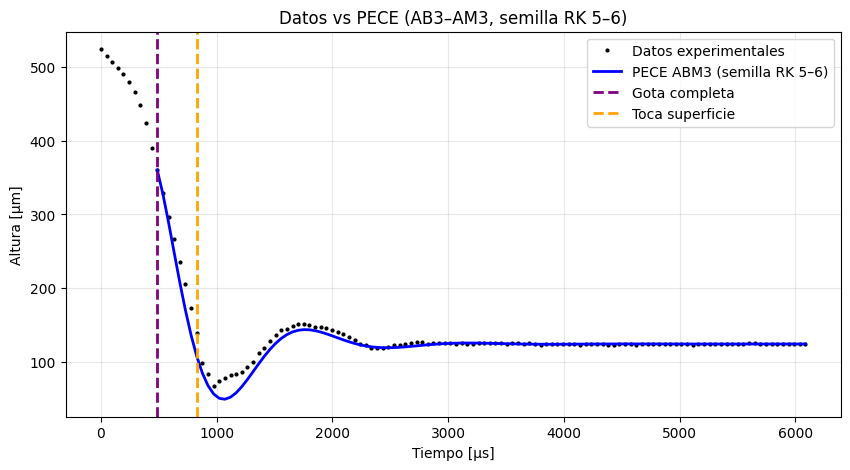

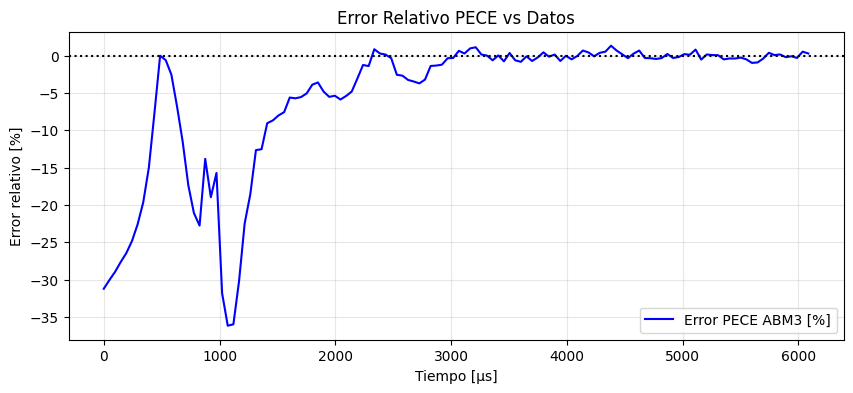

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from google.colab import files

# ==========================
# 1. CARGA Y CONVERSIÓN
# ==========================
px_to_um = 4.13             # µm/pixel
px_to_m  = px_to_um * 1e-6  # m/pixel

print("Sube 'centro_vs_tiempo.csv'")
files.upload()
df = pd.read_csv("centro_vs_tiempo.csv")

t_us = df["Tiempo en µs"].values.astype(float)
t_s  = t_us * 1e-6           # segundos
y_px = df["y_pixeles"].values.astype(float)
y_um = y_px * px_to_um       # µm
y_m  = y_um * 1e-6           # m

# ==========================
# 2. PARÁMETROS BÁSICOS
# ==========================
m = 0.110e-6                 # masa de la gota en kg
t_events_us = [486.90, 827.73]  # µs
t0_event_s  = t_events_us[0] * 1e-6
h0          = t_s[1] - t_s[0]

# ==========================
# 3. FILTRAR DESDE "GOTA COMPLETA"
# ==========================
start_idx = np.searchsorted(t_s, t0_event_s)
t_s_sub   = t_s[start_idx:]
t_us_sub  = t_us[start_idx:]
y_um_sub  = y_um[start_idx:]
y_m_sub   = y_m[start_idx:]

# ==========================
# 4. ESTIMAR PARÁMETROS
# ==========================
yeq = np.median(y_um_sub[-10:])  # en µm
z_sub = y_um_sub - yeq
win   = max(7, 2*(len(z_sub)//100) + 1)
z_s   = savgol_filter(z_sub, window_length=win, polyorder=2)

peaks_max, _ = find_peaks(z_s, prominence=1.0)
peaks_min, _ = find_peaks(-z_s, prominence=1.0)
peaks_max = peaks_max[peaks_max != 0]
peaks_min = peaks_min[peaks_min != 0]

i_max1 = peaks_max[0]
i_min1 = peaks_min[0]
T1 = t_s_sub[i_max1] - t_s_sub[0]
T2 = 2 * abs(t_s_sub[i_max1] - t_s_sub[i_min1])
T_d = 0.5 * (T1 + T2)
f_d = 1.0 / T_d

A1, A2 = abs(z_s[peaks_max[0]]), abs(z_s[peaks_max[1]])
delta  = np.log(A1 / A2)
zeta   = delta / np.sqrt((2*np.pi)**2 + delta**2)

omega_d = 2 * np.pi * f_d
omega_n = omega_d / np.sqrt(1 - zeta**2)
k = m * omega_n**2
c = 2 * m * omega_n * zeta

# ==========================
# 5. CONDICIONES INICIALES
# ==========================
yinicial = y_um_sub[0]       # en µm
v0 = (y_m_sub[1] - y_m_sub[0]) / h0  # en m/s
u0 = np.array([y_m_sub[0], v0], dtype=float)
t_final = t_s_sub[-1] - t_s_sub[0]

print("===== Parámetros obtenidos =====")
print(f"m       = {m:.3e} kg")
print(f"k       = {k:.3e} N/m")
print(f"c       = {c:.3e} kg/s")
print(f"yeq     = {yeq:.2f} µm")
print(f"yinicial= {yinicial:.2f} µm")
print(f"v0      = {v0:.3e} m/s")

# ==========================
# 6. SISTEMA Y MÉTODOS
# ==========================
def f_osc(t, u, m, k, c, yeq_m):
    y, v = u
    return np.array([v, -(c/m)*v - (k/m)*(y - yeq_m)], dtype=float)

# --- RK 5–6 paso fijo (para semilla y referencia) ---
def rk56_step(u, h, m, k, c, yeq_m):
    b = [
        [],
        [1/6],
        [4/75, 16/75],
        [5/6, -8/3, 5/2],
        [-165/64, 55/6, -425/64, 85/96],
        [12/5, -8, 4015/612, -11/36, 88/255],
        [-8263/15000, 124/75, -643/680, -81/250, 2484/10625, 0]
    ]
    c6 = [82889/524892, 0, 15625/83664, 69875/102672, -2260/8211, 0, 1/4]

    k1 = f_osc(0,u,m,k,c,yeq_m)
    k2 = f_osc(0,u + h*(b[1][0]*k1), m,k,c,yeq_m)
    k3 = f_osc(0,u + h*(b[2][0]*k1 + b[2][1]*k2), m,k,c,yeq_m)
    k4 = f_osc(0,u + h*(b[3][0]*k1 + b[3][1]*k2 + b[3][2]*k3), m,k,c,yeq_m)
    k5 = f_osc(0,u + h*(b[4][0]*k1 + b[4][1]*k2 + b[4][2]*k3 + b[4][3]*k4), m,k,c,yeq_m)
    k6 = f_osc(0,u + h*(b[5][0]*k1 + b[5][1]*k2 + b[5][2]*k3 + b[5][3]*k4 + b[5][4]*k5), m,k,c,yeq_m)
    k7 = f_osc(0,u + h*(b[6][0]*k1 + b[6][1]*k2 + b[6][2]*k3 + b[6][3]*k4 + b[6][4]*k5 + b[6][5]*k6), m,k,c,yeq_m)

    u6 = u + h*(c6[0]*k1 + c6[2]*k3 + c6[3]*k4 + c6[4]*k5 + c6[6]*k7)
    return u6

# --- Clase con PECE ABM3 ---
class ODESolver:
    def __init__(self, m, k, c, y_eq_m):
        self.m, self.k, self.c, self.y_eq = map(float,(m,k,c,y_eq_m))

    def pece_abm3(self, t0, u0, h, tf):
        # Semilla con RK56 para consistencia
        u1 = rk56_step(u0, h, self.m, self.k, self.c, self.y_eq)
        u2 = rk56_step(u1, h, self.m, self.k, self.c, self.y_eq)

        t_vals = [t0, t0+h, t0+2*h]
        u_vals = [u0, u1, u2]
        f_vals = [f_osc(t_vals[i],u_vals[i],self.m,self.k,self.c,self.y_eq) for i in range(3)]
        ts = t_vals.copy()
        ys = [u[0] for u in u_vals]

        while ts[-1] + h <= tf + 1e-15:
            fn, fn_1, fn_2 = f_vals[-1], f_vals[-2], f_vals[-3]
            un, tn = u_vals[-1], ts[-1]

            # Predictor AB3
            up = un + (h/12.0) * (23*fn - 16*fn_1 + 5*fn_2)
            tp = tn + h

            # Corrector AM3
            fp = f_osc(tp, up, self.m, self.k, self.c, self.y_eq)
            un1 = un + (h/12.0) * (5*fp + 8*fn - fn_1)

            ts.append(tp)
            ys.append(un1[0])
            u_vals.append(un1)
            f_vals.append(f_osc(tp, un1, self.m, self.k, self.c, self.y_eq))

        return np.array(ts), np.array(ys)

# ==========================
# 7. SIMULACIÓN SOLO PECE
# ==========================
solver = ODESolver(m, k, c, yeq*1e-6)
t_pece, y_pece = solver.pece_abm3(0.0, u0, h0, t_final)
t_pece_us = t_pece*1e6 + t_events_us[0]
y_pece_um = y_pece*1e6

# ==========================
# 8. COMPARACIÓN CON DATOS
# ==========================
y_pece_i = np.interp(t_us, t_pece_us, y_pece_um)
mask     = y_um != 0
t_err    = t_us[mask]
err_pece = 100*(y_pece_i[mask]-y_um[mask])/y_um[mask]

# ==========================
# 9. GRAFICAR
# ==========================
plt.figure(figsize=(10,5))
plt.plot(t_us, y_um, 'k.', markersize=4, label="Datos experimentales")
plt.plot(t_pece_us, y_pece_um, 'b-', linewidth=2, label="PECE ABM3 (semilla RK 5–6)")
for te,col,lab in zip(t_events_us,['purple','orange'],['Gota completa','Toca superficie']):
    plt.axvline(x=te, color=col, linestyle='--', linewidth=2, label=lab)
plt.xlabel("Tiempo [µs]"); plt.ylabel("Altura [µm]")
plt.title("Datos vs PECE (AB3–AM3, semilla RK 5–6)")
plt.legend(); plt.grid(alpha=0.3)

plt.figure(figsize=(10,4))
plt.plot(t_err, err_pece, 'b-', label="Error PECE ABM3 [%]")
plt.axhline(0, color='k', linestyle=':')
plt.xlabel("Tiempo [µs]"); plt.ylabel("Error relativo [%]")
plt.title("Error Relativo PECE vs Datos")
plt.legend(); plt.grid(alpha=0.3)

plt.show()

#Parte C

Sube 'centro_vs_tiempo.csv'


Saving centro_vs_tiempo.csv to centro_vs_tiempo (5).csv

===== Resultados comparativos (Richardson) =====
             Metodo         h  Error_Rich_um  Eval_f
0           Taylor3  0.000779   1.565269e+06      23
1   Runge–Kutta 5–6  0.000779   6.042505e+10     161
2         PECE ABM3  0.000779   2.843812e+08      45
3           Taylor3  0.000390   2.784636e+00      44
4   Runge–Kutta 5–6  0.000390   9.128798e+03     308
5         PECE ABM3  0.000390   7.015199e+03      66
6           Taylor3  0.000195   5.858126e-01      87
7   Runge–Kutta 5–6  0.000195   4.577208e-01     609
8         PECE ABM3  0.000195   1.597752e+00     109
9           Taylor3  0.000097   1.073073e-01     174
10  Runge–Kutta 5–6  0.000097   7.791177e-02    1218
11        PECE ABM3  0.000097   8.006990e-02     196
12          Taylor3  0.000049   2.277327e-02     347
13  Runge–Kutta 5–6  0.000049   3.020385e-02    2429
14        PECE ABM3  0.000049   2.472886e-01     369
15          Taylor3  0.000024   5.296478e-03  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

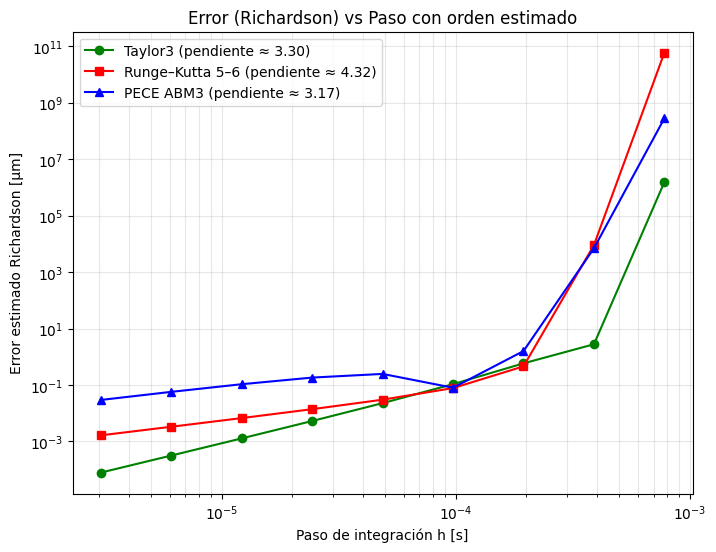

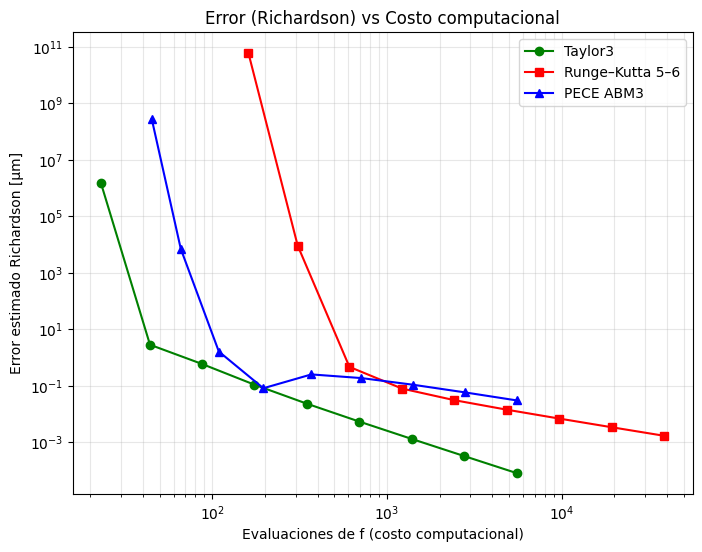

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from google.colab import files
from numpy import polyfit, log10

# ==========================
# 1. CARGA Y CONVERSIÓN
# ==========================
px_to_um = 4.13
px_to_m  = px_to_um * 1e-6

print("Sube 'centro_vs_tiempo.csv'")
files.upload()
df = pd.read_csv("centro_vs_tiempo.csv")

t_us = df["Tiempo en µs"].values.astype(float)
t_s  = t_us * 1e-6
y_px = df["y_pixeles"].values.astype(float)
y_um = y_px * px_to_um
y_m  = y_um * 1e-6

# ==========================
# 2. PARÁMETROS BÁSICOS
# ==========================
m = 0.105e-6
t_events_us = [486.90, 827.73]
t0_event_s  = t_events_us[0] * 1e-6
h_data      = t_s[1] - t_s[0]

# ==========================
# 3. FILTRAR DESDE "GOTA COMPLETA"
# ==========================
start_idx = np.searchsorted(t_s, t0_event_s)
t_us_sub  = t_us[start_idx:]
t_s_sub   = t_s[start_idx:]
y_um_sub  = y_um[start_idx:]
y_m_sub   = y_m[start_idx:]

# ==========================
# 4. ESTIMAR PARÁMETROS
# ==========================
yeq_um = np.median(y_um_sub[-10:])
z_sub  = y_um_sub - yeq_um
win    = max(7, 2*(len(z_sub)//100) + 1)
z_s    = savgol_filter(z_sub, window_length=win, polyorder=2)

peaks_max, _ = find_peaks(z_s, prominence=1.0)
peaks_min, _ = find_peaks(-z_s, prominence=1.0)
peaks_max = peaks_max[peaks_max != 0]
peaks_min = peaks_min[peaks_min != 0]

i_max1 = peaks_max[0]
i_min1 = peaks_min[0]
T1 = t_s_sub[i_max1] - t_s_sub[0]
T2 = 2 * abs(t_s_sub[i_max1] - t_s_sub[i_min1])
T_d = 0.5 * (T1 + T2)
f_d = 1.0 / T_d

A1, A2 = abs(z_s[peaks_max[0]]), abs(z_s[peaks_max[1]])
delta  = np.log(A1 / A2)
zeta   = delta / np.sqrt((2*np.pi)**2 + delta**2)

omega_d = 2*np.pi*f_d
omega_n = omega_d/np.sqrt(1 - zeta**2)
k = m * omega_n**2
c = 2 * m * omega_n * zeta
yeq_m = yeq_um * 1e-6

# condiciones iniciales
y0 = y_m_sub[0]
v0 = (y_m_sub[1] - y_m_sub[0]) / h_data
u0 = np.array([y0, v0], dtype=float)
t_final = t_s_sub[-1] - t_s_sub[0]

# ==========================
# 5. SISTEMA
# ==========================
def f_osc(u, m, k, c, yeq_m):
    y, v = u
    return np.array([v, -(c/m)*v - (k/m)*(y - yeq_m)], dtype=float)

# ==========================
# 6. SOLVERS
# ==========================
def solver_taylor3(u0, h, tf, m, k, c, yeq_m):
    t, u = 0.0, u0.copy()
    ts, ys = [t],[u[0]]
    n_eval = 0
    while t < tf - 1e-15:
        y,v = u
        y1 = v
        v1 = -(c/m)*v - (k/m)*(y-yeq_m)
        y2 = v1
        v2 = -(c/m)*v1 - (k/m)*y1
        y3 = v2
        v3 = -(c/m)*v2 - (k/m)*y2
        y_n = y + h*y1 + 0.5*h*h*y2 + (h**3)*y3/6.0
        v_n = v + h*v1 + 0.5*h*h*v2 + (h**3)*v3/6.0
        u = np.array([y_n,v_n])
        t += h
        ts.append(t); ys.append(u[0])
        n_eval += 1
    return np.array(ts), np.array(ys), n_eval

def solver_rk56(u0, h, tf, m, k, c, yeq_m):
    b = [
        [],
        [1/6],
        [4/75, 16/75],
        [5/6, -8/3, 5/2],
        [-165/64, 55/6, -425/64, 85/96],
        [12/5, -8, 4015/612, -11/36, 88/255],
        [-8263/15000, 124/75, -643/680, -81/250, 2484/10625, 0]
    ]
    c6 = [82889/524892, 0, 15625/83664, 69875/102672, -2260/8211, 0, 1/4]

    t, u = 0.0, u0.copy()
    ts, ys = [t], [u[0]]
    n_eval = 0

    while t < tf - 1e-15:
        if t + h > tf:
            h = tf - t
        k1 = f_osc(u, m,k,c,yeq_m)
        k2 = f_osc(u + h*(b[1][0]*k1), m,k,c,yeq_m)
        k3 = f_osc(u + h*(b[2][0]*k1 + b[2][1]*k2), m,k,c,yeq_m)
        k4 = f_osc(u + h*(b[3][0]*k1 + b[3][1]*k2 + b[3][2]*k3), m,k,c,yeq_m)
        k5 = f_osc(u + h*(b[4][0]*k1 + b[4][1]*k2 + b[4][2]*k3 + b[4][3]*k4), m,k,c,yeq_m)
        k6 = f_osc(u + h*(b[5][0]*k1 + b[5][1]*k2 + b[5][2]*k3 + b[5][3]*k4 + b[5][4]*k5), m,k,c,yeq_m)
        k7 = f_osc(u + h*(b[6][0]*k1 + b[6][1]*k2 + b[6][2]*k3 + b[6][3]*k4 + b[6][4]*k5 + b[6][5]*k6), m,k,c,yeq_m)

        u6 = u + h*(c6[0]*k1 + c6[2]*k3 + c6[3]*k4 + c6[4]*k5 + c6[6]*k7)

        u = u6
        t += h
        ts.append(t); ys.append(u[0])
        n_eval += 7
    return np.array(ts), np.array(ys), n_eval

def rk56_step(u, h, m, k, c, yeq_m):
    # un solo paso de RK56 (orden 6)
    _, ys, _ = solver_rk56(u, h, h, m, k, c, yeq_m)
    return np.array([ys[-1], (ys[-1]-ys[-2])/h])

def solver_pece(u0, h, tf, m, k, c, yeq_m):
    # Semilla con RK56
    u1 = rk56_step(u0, h, m, k, c, yeq_m)
    u2 = rk56_step(u1, h, m, k, c, yeq_m)
    t_vals = [0.0, h, 2*h]
    u_vals = [u0, u1, u2]
    f_vals = [f_osc(u,m,k,c,yeq_m) for u in u_vals]
    ts = t_vals.copy()
    ys = [u[0] for u in u_vals]
    n_eval = 2*7  # dos pasos RK56 de semilla = 14 evaluaciones

    while ts[-1] + h <= tf + 1e-15:
        fn, fn1, fn2 = f_vals[-1], f_vals[-2], f_vals[-3]
        un = u_vals[-1]

        # Predictor AB3
        up = un + (h/12.0)*(23*fn - 16*fn1 + 5*fn2)
        tp = ts[-1] + h

        # Corrector AM3
        fp = f_osc(up, m, k, c, yeq_m); n_eval += 1
        un1 = un + (h/12.0)*(5*fp + 8*fn - fn1)

        ts.append(tp); ys.append(un1[0])
        u_vals.append(un1)
        f_vals.append(f_osc(un1, m, k, c, yeq_m))

    return np.array(ts), np.array(ys), n_eval

# ==========================
# 7. FUNCIÓN DE ERROR RICHARDSON
# ==========================
def richardson_error(solver, u0, h, tf, m, k, c, yeq_m, p):
    t_h, y_h, eval_h = solver(u0, h, tf, m, k, c, yeq_m)
    t_h2, y_h2, eval_h2 = solver(u0, h/2, tf, m, k, c, yeq_m)
    t_ref = t_h2
    y_h_interp = np.interp(t_ref, t_h, y_h)
    err = (y_h2 - y_h_interp) / (2**p - 1)
    err_rms = np.sqrt(np.mean(err**2))*1e6  # en µm
    eval_total = eval_h + eval_h2
    return err_rms, eval_total

# ==========================
# 8. BARRIDO DE PASOS
# ==========================
h_list = [16*h_data, 8*h_data, 4*h_data, 2*h_data, h_data,
          h_data/2, h_data/4, h_data/8, h_data/16]
results = []

for h in h_list:
    # Taylor3 (orden 3)
    err_tay, eval_tay = richardson_error(solver_taylor3, u0, h, t_final, m,k,c,yeq_m, p=3)
    results.append({"Metodo":"Taylor3", "h":h, "Error_Rich_um":err_tay, "Eval_f":eval_tay})

    # RK 5–6 (orden 6)
    err_rk, eval_rk = richardson_error(solver_rk56, u0, h, t_final, m,k,c,yeq_m, p=6)
    results.append({"Metodo":"Runge–Kutta 5–6", "h":h, "Error_Rich_um":err_rk, "Eval_f":eval_rk})

    # PECE (orden 3, semilla RK56)
    err_pece, eval_pece = richardson_error(solver_pece, u0, h, t_final, m,k,c,yeq_m, p=3)
    results.append({"Metodo":"PECE ABM3", "h":h, "Error_Rich_um":err_pece, "Eval_f":eval_pece})

# ==========================
# 9. EXPORTAR A CSV
# ==========================
df_results = pd.DataFrame(results)
df_results.to_csv("comparacion_metodos.csv", index=False)
print("\n===== Resultados comparativos (Richardson) =====")
print(df_results)
files.download("comparacion_metodos.csv")

# ==========================
# 10. GRÁFICO ERROR vs PASO
# ==========================
plt.figure(figsize=(8,6))
for metodo, color, marker in zip(["Taylor3","Runge–Kutta 5–6","PECE ABM3"],
                                 ["green","red","blue"],
                                 ["o","s","^"]):
    subset = df_results[df_results["Metodo"]==metodo].sort_values("h")
    x = log10(subset["h"].values)
    y = log10(subset["Error_Rich_um"].values)
    if len(x) > 1:
        slope, _ = polyfit(x, y, 1)
    else:
        slope = np.nan
    plt.loglog(subset["h"], subset["Error_Rich_um"],
               marker=marker, color=color, linestyle='-',
               label=f"{metodo} (pendiente ≈ {slope:.2f})")

plt.xlabel("Paso de integración h [s]")
plt.ylabel("Error estimado Richardson [µm]")
plt.title("Error (Richardson) vs Paso con orden estimado")
plt.legend(); plt.grid(which="both", alpha=0.3)
plt.show()

# ==========================
# 11. GRÁFICO ERROR vs COSTO
# ==========================
plt.figure(figsize=(8,6))
for metodo, color, marker in zip(["Taylor3","Runge–Kutta 5–6","PECE ABM3"],
                                 ["green","red","blue"],
                                 ["o","s","^"]):
    subset = df_results[df_results["Metodo"]==metodo].sort_values("Eval_f")
    plt.loglog(subset["Eval_f"], subset["Error_Rich_um"],
               marker=marker, color=color, linestyle='-', label=metodo)

plt.xlabel("Evaluaciones de f (costo computacional)")
plt.ylabel("Error estimado Richardson [µm]")
plt.title("Error (Richardson) vs Costo computacional")
plt.legend(); plt.grid(which="both", alpha=0.3)
plt.show()